In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## RAMACHANDRAN DEL AMINOÁCIDO ENTERO

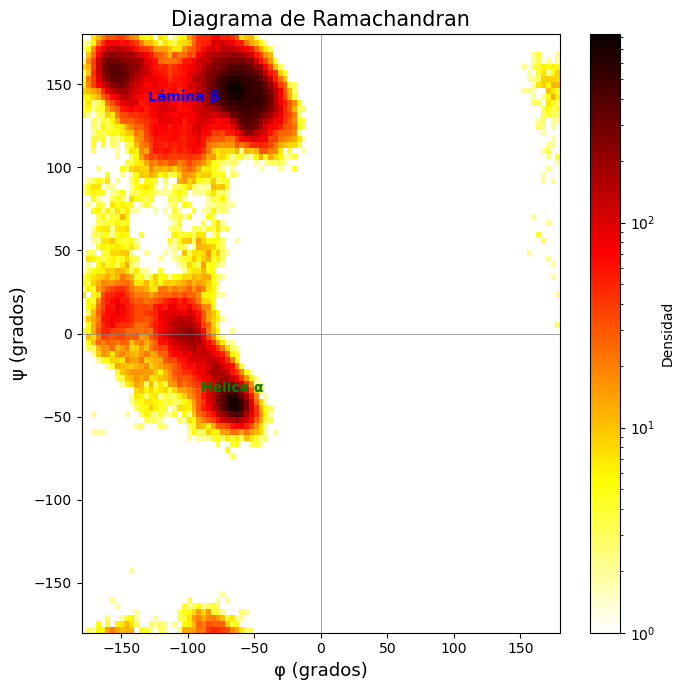

In [3]:
# Cargar datos (saltando líneas de cabecera)
data = []
with open("ramachandran.xvg", "r") as f:
    for line in f:
        if line.startswith("#") or line.startswith("@"):
            continue
        cols = line.split()
        if len(cols) >= 2:
            data.append([float(cols[0]), float(cols[1])])

data = np.array(data)
phi = data[:, 0]
psi = data[:, 1]

# Crear figura
fig, ax = plt.subplots(figsize=(7, 7))

# Mapa de densidad (más informativo)
h = ax.hist2d(phi, psi, bins=100, 
              range=[[-180,180],[-180,180]], 
              norm=LogNorm(), cmap="hot_r")
plt.colorbar(h[3], ax=ax, label="Densidad")

# Formato
ax.set_xlabel("φ (grados)", fontsize=13)
ax.set_ylabel("ψ (grados)", fontsize=13)
ax.set_title("Diagrama de Ramachandran", fontsize=15)
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)

# Anotar regiones
ax.text(-90, -35, "Hélice α", color="green", fontsize=10, fontweight="bold")
ax.text(-130, 140, "Lámina β", color="blue", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("ramachandran.png", dpi=150)
plt.show()

## RAMANCHANDRAN POR SEPARADO

In [ ]:
# Cargar datos separados por residuo
residues = {}
with open("ramachandran.xvg", "r") as f:
    for line in f:
        if line.startswith("#") or line.startswith("@"):
            continue
        cols = line.split()
        if len(cols) >= 3:
            phi, psi, res = float(cols[0]), float(cols[1]), cols[2]
            if res not in residues:
                residues[res] = {"phi": [], "psi": []}
            residues[res]["phi"].append(phi)
            residues[res]["psi"].append(psi)

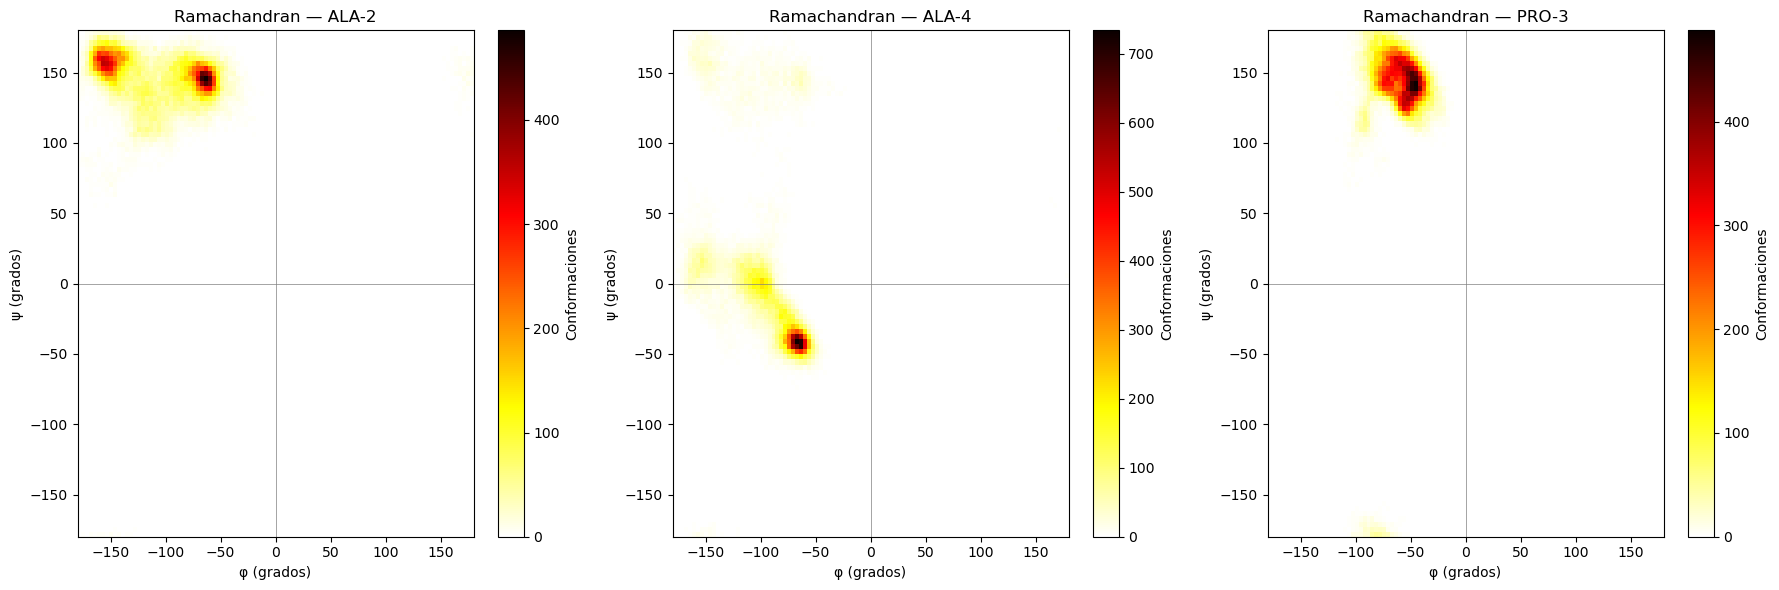

In [5]:
# Un subplot por residuo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (res, vals) in zip(axes, sorted(residues.items())):
    phi = np.array(vals["phi"])
    psi = np.array(vals["psi"])
    
    h = ax.hist2d(phi, psi, bins=100,
                  range=[[-180,180],[-180,180]],
                  cmap="hot_r")
    plt.colorbar(h[3], ax=ax, label="Conformaciones")
    
    ax.set_xlabel("φ (grados)")
    ax.set_ylabel("ψ (grados)")
    ax.set_title(f"Ramachandran — {res}")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-180, 180)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.savefig("ramachandran_por_residuo.png", dpi=150)
plt.show()